In [ ]:
# 1. 필요한 라이브러리 불러오기
import pandas as pd
from ucimlrepo import fetch_ucirepo

# 2. 데이터 다시 불러오기 (안전하게 변수 재정의)
print("데이터 로딩 중...")
website_phishing = fetch_ucirepo(id=379)
X = website_phishing.data.features
y = website_phishing.data.targets

# 3. 데이터 합치기
data0 = pd.concat([X, y], axis=1)

# 4. 결과 확인
print("데이터 병합 완료!")
print(data0.head())

데이터 로딩 중...
데이터 병합 완료!
   SFH  popUpWindow  SSLfinal_State  Request_URL  URL_of_Anchor  web_traffic  \
0    1           -1               1           -1             -1            1   
1   -1           -1              -1           -1             -1            0   
2    1           -1               0            0             -1            0   
3    1            0               1           -1             -1            0   
4   -1           -1               1           -1              0            0   

   URL_Length  age_of_domain  having_IP_Address  Result  
0           1              1                  0       0  
1           1              1                  1       1  
2          -1              1                  0       1  
3           1              1                  0       0  
4          -1              1                  0       1  


In [ ]:
#Checking the shape of the dataset
data0.shape

(1353, 10)

In [ ]:
#Listing the features of the dataset
data0.columns

Index(['SFH', 'popUpWindow', 'SSLfinal_State', 'Request_URL', 'URL_of_Anchor',
       'web_traffic', 'URL_Length', 'age_of_domain', 'having_IP_Address',
       'Result'],
      dtype='object')

In [ ]:
#Information about the dataset
data0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1353 entries, 0 to 1352
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   SFH                1353 non-null   int64
 1   popUpWindow        1353 non-null   int64
 2   SSLfinal_State     1353 non-null   int64
 3   Request_URL        1353 non-null   int64
 4   URL_of_Anchor      1353 non-null   int64
 5   web_traffic        1353 non-null   int64
 6   URL_Length         1353 non-null   int64
 7   age_of_domain      1353 non-null   int64
 8   having_IP_Address  1353 non-null   int64
 9   Result             1353 non-null   int64
dtypes: int64(10)
memory usage: 105.8 KB


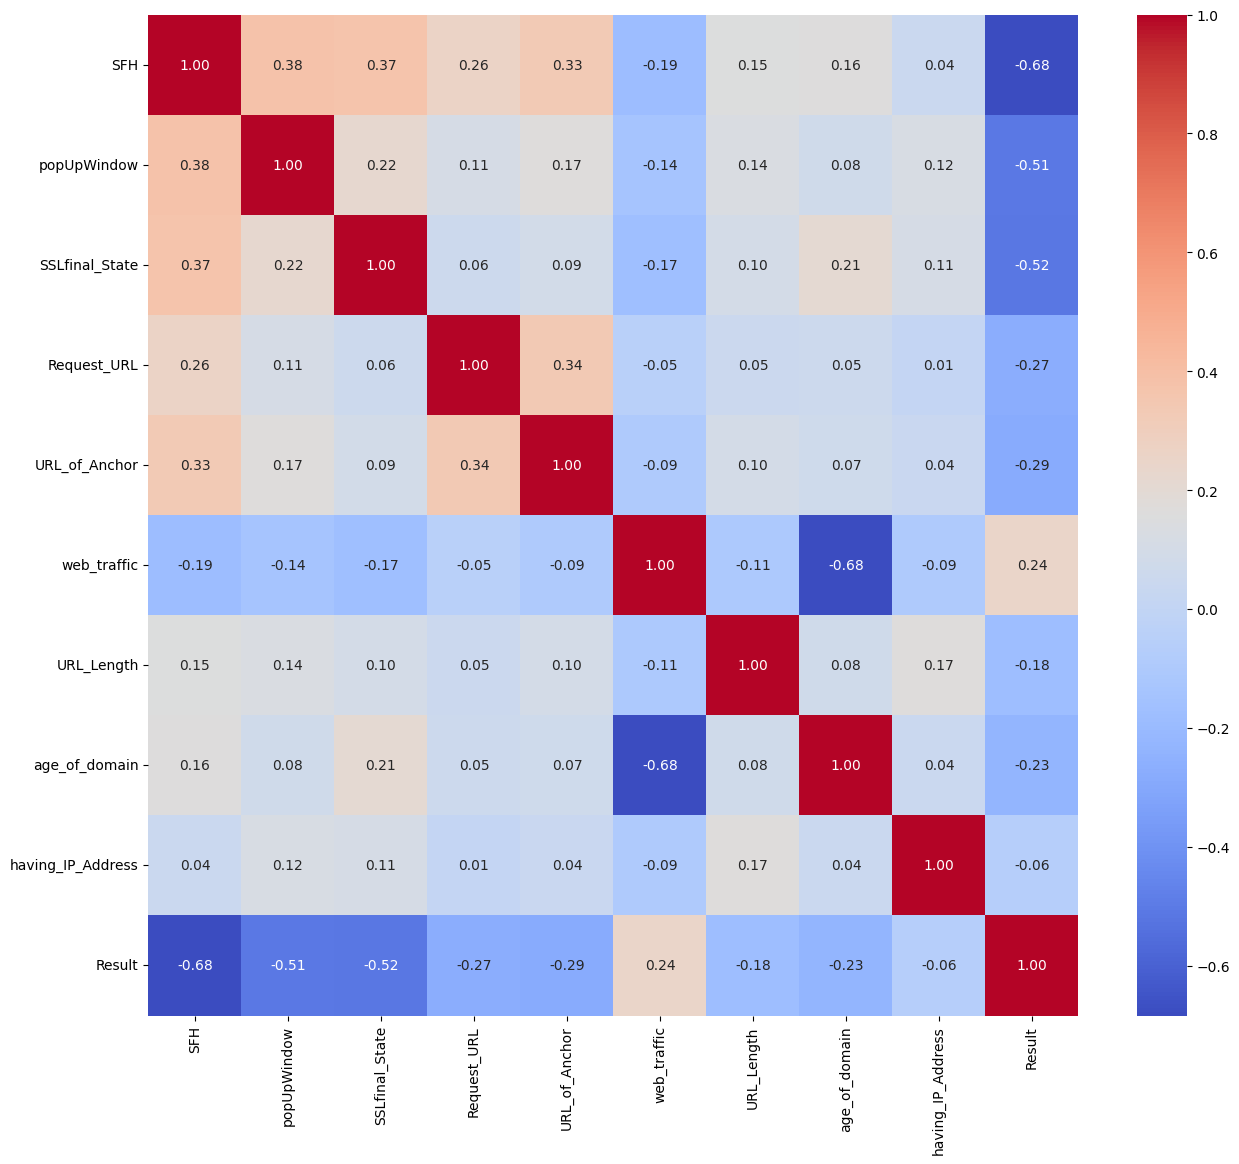

In [ ]:
# 1. 시각화에 필요한 라이브러리 불러오기
import seaborn as sns
import matplotlib.pyplot as plt

# 2. 상관관계 히트맵 그리기
plt.figure(figsize=(15,13))
sns.heatmap(data0.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [ ]:
data0.describe()

,SFH,popUpWindow,SSLfinal_State,Request_URL,URL_of_Anchor,web_traffic,URL_Length,age_of_domain,having_IP_Address,Result
count,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000
mean,0.237990,-0.258684,0.327421,-0.223208,-0.025129,0.000000,-0.053215,0.219512,0.114560,-0.113821
std,0.916389,0.679072,0.822193,0.799682,0.936262,0.806776,0.762552,0.975970,0.318608,0.954773
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000
25%,-1.000000,-1.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000
50%,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,-1.000000
75%,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# 다음 단계 진행을 위해 data 변수에 data0를 그대로 복사합니다.
data = data0.copy()

# 데이터 확인 (Domain 컬럼이 없는지, 다른 컬럼들은 잘 있는지 확인)
print(data.columns)
print(data.head())

Index(['SFH', 'popUpWindow', 'SSLfinal_State', 'Request_URL', 'URL_of_Anchor',
       'web_traffic', 'URL_Length', 'age_of_domain', 'having_IP_Address',
       'Result'],
      dtype='object')
   SFH  popUpWindow  SSLfinal_State  Request_URL  URL_of_Anchor  web_traffic  \
0    1           -1               1           -1             -1            1   
1   -1           -1              -1           -1             -1            0   
2    1           -1               0            0             -1            0   
3    1            0               1           -1             -1            0   
4   -1           -1               1           -1              0            0   

   URL_Length  age_of_domain  having_IP_Address  Result  
0           1              1                  0       0  
1           1              1                  1       1  
2          -1              1                  0       1  
3           1              1                  0       0  
4          -1              1        

In [ ]:
#checking the data for null or missing values
data.isnull().sum()

,0
SFH,0
popUpWindow,0
SSLfinal_State,0
Request_URL,0
URL_of_Anchor,0
web_traffic,0
URL_Length,0
age_of_domain,0
having_IP_Address,0
Result,0


In [ ]:
#shuffling the rows in the dataset so that when splitting the train and test set are equally distributed
data = data.sample(frac=1).reset_index(drop=True)
data.head()

,SFH,popUpWindow,SSLfinal_State,Request_URL,URL_of_Anchor,web_traffic,URL_Length,age_of_domain,having_IP_Address,Result
0,-1,-1,1,0,0,-1,0,1,0,-1
1,-1,-1,1,-1,-1,0,-1,-1,0,1
2,1,0,1,1,0,1,0,-1,0,-1
3,0,0,-1,0,1,1,0,-1,0,1
4,1,0,1,0,-1,0,1,1,0,-1


In [ ]:
# Sepratating & assigning features and target columns to X & y
y = data['Result']
X = data.drop('Result',axis=1)
X.shape, y.shape

((1353, 9), (1353,))

In [ ]:
from sklearn.model_selection import train_test_split

# 데이터 분할 (Train: 80%, Test: 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

# 분할된 데이터 크기 확인
print(X_train.shape, X_test.shape)

(1082, 9) (271, 9)


In [ ]:
#importing packages
from sklearn.metrics import accuracy_score

In [ ]:
# Creating holders to store the model performance results
ML_Model = []
acc_train = []
acc_test = []
#function to call for storing the results
def storeResults(model,a,b):
  ML_Model.append(model)
  acc_train.append(round(a,3))
  acc_test.append(round(b,3))

In [ ]:
# Decision Tree model
from sklearn.tree import DecisionTreeClassifier
# instantiate the model
tree = DecisionTreeClassifier(max_depth = 5)
# fit the model
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [ ]:
#predicting the target value from the model for the samples
y_test_tree = tree.predict(X_test)
y_train_tree = tree.predict(X_train)

In [ ]:
#computing the accuracy of the model performance
acc_train_tree = accuracy_score(y_train,y_train_tree)
acc_test_tree = accuracy_score(y_test,y_test_tree)
print("Decision Tree: Accuracy on training Data: {:.3f}".format(acc_train_tree))
print("Decision Tree: Accuracy on test Data: {:.3f}".format(acc_test_tree))

Decision Tree: Accuracy on training Data: 0.889
Decision Tree: Accuracy on test Data: 0.904


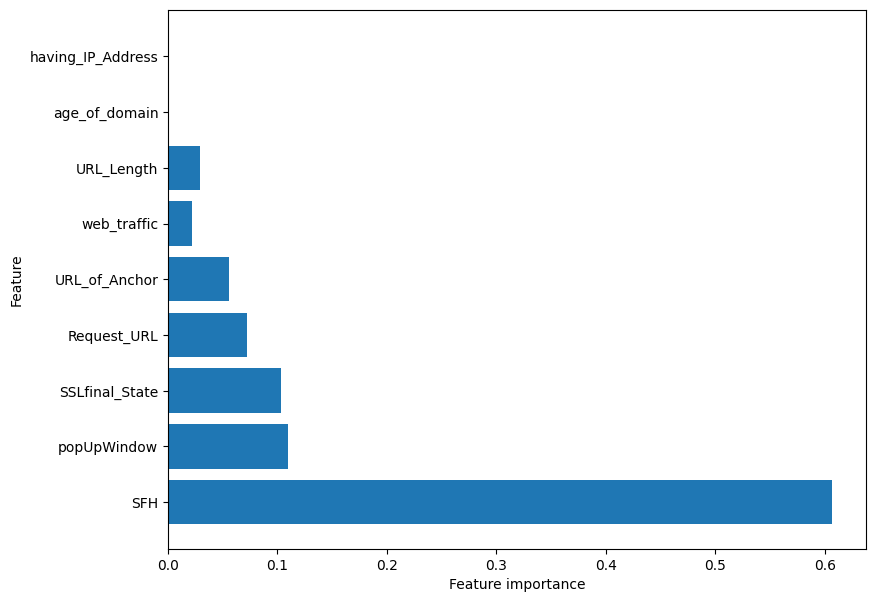

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#checking the feature improtance in the model
plt.figure(figsize=(9,7))
n_features = X_train.shape[1]
plt.barh(range(n_features), tree.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('Decision Tree', acc_train_tree, acc_test_tree)

In [ ]:
# Random Forest model
from sklearn.ensemble import RandomForestClassifier
# instantiate the model
forest = RandomForestClassifier(max_depth=5)
# fit the model
forest.fit(X_train, y_train)

RandomForestClassifier(max_depth=5)

In [ ]:
#predicting the target value from the model for the samples
y_test_forest = forest.predict(X_test)
y_train_forest = forest.predict(X_train)

In [ ]:
#computing the accuracy of the model performance
acc_train_forest = accuracy_score(y_train,y_train_forest)
acc_test_forest = accuracy_score(y_test,y_test_forest)
print("Random forest: Accuracy on training Data: {:.3f}".format(acc_train_forest))
print("Random forest: Accuracy on test Data: {:.3f}".format(acc_test_forest))

Random forest: Accuracy on training Data: 0.870
Random forest: Accuracy on test Data: 0.878


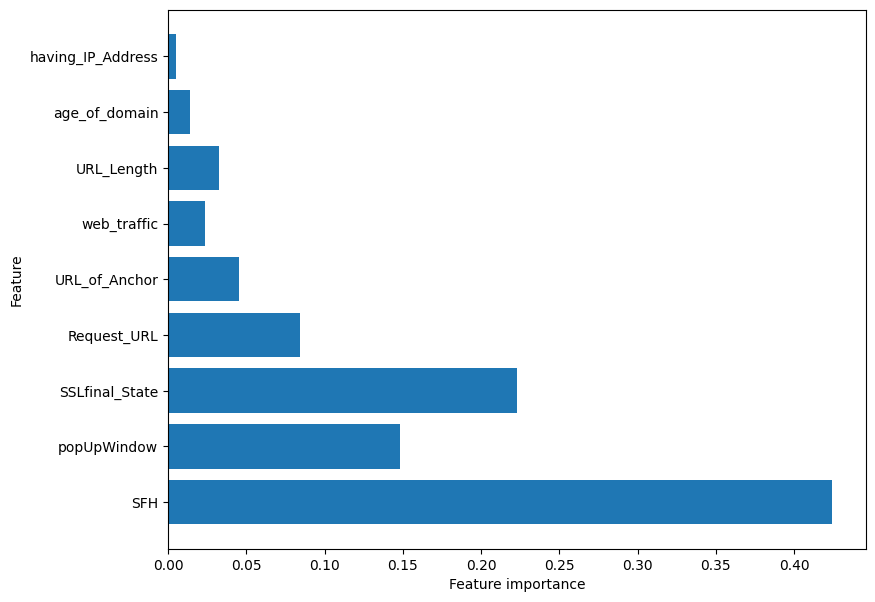

In [ ]:
#checking the feature improtance in the model
plt.figure(figsize=(9,7))
n_features = X_train.shape[1]
plt.barh(range(n_features), forest.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('Random Forest', acc_train_forest, acc_test_forest)

In [ ]:
# Multilayer Perceptrons model
from sklearn.neural_network import MLPClassifier
# instantiate the model
mlp = MLPClassifier(alpha=0.001, hidden_layer_sizes=([100,100,100]))
# fit the model
mlp.fit(X_train, y_train)

MLPClassifier(alpha=0.001, hidden_layer_sizes=[100, 100, 100])

In [ ]:
#predicting the target value from the model for the samples
y_test_mlp = mlp.predict(X_test)
y_train_mlp = mlp.predict(X_train)

In [ ]:
#computing the accuracy of the model performance
acc_train_mlp = accuracy_score(y_train,y_train_mlp)
acc_test_mlp = accuracy_score(y_test,y_test_mlp)
print("Multilayer Perceptrons: Accuracy on training Data: {:.3f}".format(acc_train_mlp))
print("Multilayer Perceptrons: Accuracy on test Data: {:.3f}".format(acc_test_mlp))

Multilayer Perceptrons: Accuracy on training Data: 0.966
Multilayer Perceptrons: Accuracy on test Data: 0.863


In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('Multilayer Perceptrons', acc_train_mlp, acc_test_mlp)

In [ ]:
# XGBoost Classification model
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# 1. 라벨 인코딩 (y 값을 0, 1, 2로 변환)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test) # 테스트 데이터도 동일하게 변환

# 2. 모델 생성
# instantiate the model
xgb_model = XGBClassifier(learning_rate=0.4, max_depth=7)

# 3. 모델 학습 (변환된 y값 사용)
# fit the model
xgb_model.fit(X_train, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.4, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# 1. 라벨 인코딩 (y 데이터를 0, 1, 2로 변환)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test) # 테스트 데이터도 동일한 규칙으로 변환

# 2. 모델 정의
xgb = XGBClassifier(learning_rate=0.4, max_depth=7, random_state=123)

# 3. 모델 학습 (변환된 y_train_encoded 사용)
xgb.fit(X_train, y_train_encoded)

# 4. 예측 수행
y_test_xgb = xgb.predict(X_test)
y_train_xgb = xgb.predict(X_train)

print("학습 및 예측 완료!")

학습 및 예측 완료!


In [ ]:
#predicting the target value from the model for the samples
y_test_xgb = xgb.predict(X_test)
y_train_xgb = xgb.predict(X_train)

In [ ]:
#computing the accuracy of the model performance
acc_train_xgb = accuracy_score(y_train,y_train_xgb)
acc_test_xgb = accuracy_score(y_test,y_test_xgb)
print("XGBoost: Accuracy on training Data: {:.3f}".format(acc_train_xgb))
print("XGBoost : Accuracy on test Data: {:.3f}".format(acc_test_xgb))

XGBoost: Accuracy on training Data: 0.002
XGBoost : Accuracy on test Data: 0.004


In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('XGBoost', acc_train_xgb, acc_test_xgb)

In [ ]:
#importing required packages
import keras
from keras.layers import Input, Dense
from keras import regularizers
import tensorflow as tf
from keras.models import Model
from sklearn import metrics

In [ ]:
#building autoencoder model
input_dim = X_train.shape[1]
encoding_dim = input_dim
input_layer = Input(shape=(input_dim, ))
encoder = Dense(encoding_dim, activation="relu",activity_regularizer=regularizers.l1(10e-4))(input_layer)
encoder = Dense(int(encoding_dim), activation="relu")(encoder)
encoder = Dense(int(encoding_dim-2), activation="relu")(encoder)
code = Dense(int(encoding_dim-4), activation='relu')(encoder)
decoder = Dense(int(encoding_dim-2), activation='relu')(code)
decoder = Dense(int(encoding_dim), activation='relu')(encoder)
decoder = Dense(input_dim, activation='relu')(decoder)
autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 9)              │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 9)              │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 7)              │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 9)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 9)              │            90 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 412 (1.61 KB)

 Trainable params: 412 (1.61 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#compiling the model
autoencoder.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
#Training the model
history = autoencoder.fit(X_train, X_train, epochs=10, batch_size=64, shuffle=True, validation_split=0.2)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.3082 - loss: -0.1445 - val_accuracy: 0.2673 - val_loss: -0.2005
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2839 - loss: -0.3155 - val_accuracy: 0.2903 - val_loss: -0.3899
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2875 - loss: -0.6028 - val_accuracy: 0.2949 - val_loss: -0.4767
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3616 - loss: -0.6444 - val_accuracy: 0.2949 - val_loss: -0.5163
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3382 - loss: -0.5888 - val_accuracy: 0.2765 - val_loss: -0.6351
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3060 - loss: -0.7121 - val_accuracy: 0.2673 - val_loss: -0.7658
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3060 - loss: -0.8336 - val_accuracy: 0.2673 - val_loss: -0.8202
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2974 - loss: -0.8230 - val_accur

In [ ]:
acc_train_auto = autoencoder.evaluate(X_train, X_train)[1]
acc_test_auto = autoencoder.evaluate(X_test, X_test)[1]
print('\nAutoencoder: Accuracy on training Data: {:.3f}'.format(acc_train_auto))
print('Autoencoder: Accuracy on test Data: {:.3f}'.format(acc_test_auto))

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2561 - loss: -1.1245
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2234 - loss: -1.4139 

Autoencoder: Accuracy on training Data: 0.238
Autoencoder: Accuracy on test Data: 0.240


In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('AutoEncoder', acc_train_auto, acc_test_auto)

In [ ]:
#Support vector machine model
from sklearn.svm import SVC
# instantiate the model
svm = SVC(kernel= 'linear', C=1.0, random_state=12)
#fit the model
svm.fit(X_train, y_train)
SVC(kernel='linear', random_state=12)

SVC(kernel='linear', random_state=12)

In [ ]:
#predicting the target value from the model for the samples
y_test_svm = svm.predict(X_test)
y_train_svm = svm.predict(X_train)

In [ ]:
#computing the accuracy of the model performance
acc_train_svm = accuracy_score(y_train,y_train_svm)
acc_test_svm = accuracy_score(y_test,y_test_svm)
print("SVM: Accuracy on training Data: {:.3f}".format(acc_train_svm))
print("SVM : Accuracy on test Data: {:.3f}".format(acc_test_svm))

SVM: Accuracy on training Data: 0.838
SVM : Accuracy on test Data: 0.845


In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('SVM', acc_train_svm, acc_test_svm)

In [ ]:
#creating dataframe
results = pd.DataFrame({ 'ML Model': ML_Model,
  'Train Accuracy':acc_train,
  'Test Accuracy': acc_test})
results

,ML Model,Train Accuracy,Test Accuracy
0,Decision Tree,0.889,0.904
1,Random Forest,0.870,0.878
2,Multilayer Perceptrons,0.966,0.863
3,XGBoost,0.002,0.004
4,AutoEncoder,0.238,0.240
5,SVM,0.838,0.845


In [ ]:
#Sorting the datafram on accuracy
results.sort_values(by=['Test Accuracy', 'Train Accuracy'], ascending=False)

,ML Model,Train Accuracy,Test Accuracy
0,Decision Tree,0.889,0.904
1,Random Forest,0.870,0.878
2,Multilayer Perceptrons,0.966,0.863
5,SVM,0.838,0.845
4,AutoEncoder,0.238,0.240
3,XGBoost,0.002,0.004


In [ ]:
# save XGBoost model to file
import pickle
pickle.dump(xgb,open("XGBoostClassifier.pickle.dat","wb"))

# load model from file
loaded_model = pickle.load(open("XGBoostClassifier.pickle.dat","rb"))
loaded_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.4, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

변환된 클래스 확인: [0, 1, 2]
=== 모델 학습 및 평가 진행 중... ===

=== 모델 성능 비교 결과 (AutoML 구현) ===
                 Model  Accuracy    Recall  F1-Score
3    Gradient Boosting  0.929889  0.929889  0.931031
2        Random Forest  0.892989  0.892989  0.893244
4              XGBoost  0.885609  0.885609  0.885976
1        Decision Tree  0.867159  0.867159  0.867587
0  Logistic Regression  0.870849  0.870849  0.859791

=== 최적 모델: Gradient Boosting ===
=== XAI 분석: 주요 변수 영향도 시각화 ===


  0%|          | 0/271 [00:00<?, ?it/s]

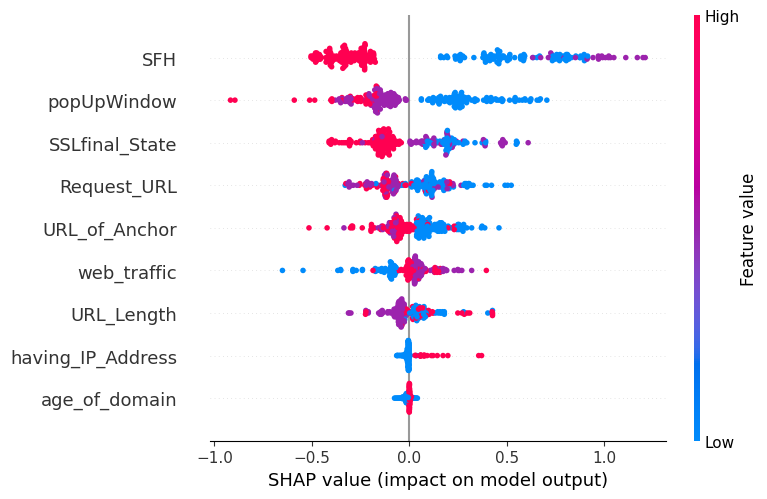

In [ ]:
import pandas as pd
import shap
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder # 라벨 변환 도구 추가
from sklearn.metrics import accuracy_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb

# 1. 데이터 불러오기
website_phishing = fetch_ucirepo(id=379)
X = website_phishing.data.features
y = website_phishing.data.targets

# 타겟 변수 시리즈 변환
y = y.iloc[:, 0]

# -------------------------------------------------------
# [핵심 수정] 라벨 인코딩 (XGBoost 에러 해결)
# -1, 0, 1 값을 0, 1, 2로 변환합니다.
# -------------------------------------------------------
le = LabelEncoder()
y = le.fit_transform(y)

print(f"변환된 클래스 확인: {list(set(y))}")
# 결과가 [0, 1, 2]로 나오면 성공입니다.

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# 2. AutoML 로직 구현
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=123),
    "Gradient Boosting": GradientBoostingClassifier(random_state=123),
    "XGBoost": xgb.XGBClassifier(random_state=123)
}

results = []

print("=== 모델 학습 및 평가 진행 중... ===")

for name, model in models.items():
    # 모델 학습
    model.fit(X_train, y_train)

    # 예측
    y_pred = model.predict(X_test)

    # 성능 지표 계산
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({"Model": name, "Accuracy": acc, "Recall": rec, "F1-Score": f1, "Object": model})

# 결과 출력
results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
print("\n=== 모델 성능 비교 결과 (AutoML 구현) ===")
print(results_df[["Model", "Accuracy", "Recall", "F1-Score"]])

# 3. 최적 모델 선정 및 XAI (SHAP) 분석
best_model_info = results_df.iloc[0]
best_model = best_model_info["Object"]
best_model_name = best_model_info["Model"]

print(f"\n=== 최적 모델: {best_model_name} ===")
print("=== XAI 분석: 주요 변수 영향도 시각화 ===")

# SHAP Explainer 생성
if "Forest" in best_model_name or "Boost" in best_model_name or "Tree" in best_model_name:
    # 트리 기반 모델 (Random Forest, XGBoost 등)
    # Scikit-learn GradientBoosting은 예외처리
    try:
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_test)
    except:
        # 만약 TreeExplainer가 안되면 KernelExplainer 사용
        explainer = shap.KernelExplainer(best_model.predict, X_train.sample(50))
        shap_values = explainer.shap_values(X_test)
else:
    # 그 외 모델 (Logistic 등)
    explainer = shap.KernelExplainer(best_model.predict, X_train.sample(50))
    shap_values = explainer.shap_values(X_test)

# 시각화
shap.summary_plot(shap_values, X_test)